# AI Waste Sorter

### Project Overview
In this project we try to build an AI model that can classify the kind of waste into 12 classes from images.

This notebook is conatain exploration process of the dataset for this project. And also after exploration there's some preprocessing to prepare the data before model training

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
from pathlib import Path
from collections import Counter
import shutil
from tqdm import tqdm
import json

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Setup Path & Configuration

In [2]:
BASE_DIR = Path.cwd()
DATASET_DIR = BASE_DIR / 'garbage_classification'
OUTPUT_DIR = BASE_DIR / 'processed_data'
OUTPUT_DIR.mkdir(exist_ok=True)

TRAIN_DIR = OUTPUT_DIR / 'train'
VAL_DIR = OUTPUT_DIR / 'val'
TEST_DIR = OUTPUT_DIR / 'test'

for dir_path in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    dir_path.mkdir(exist_ok=True)

print(f"Dataset directory: {DATASET_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Dataset exists: {DATASET_DIR.exists()}")

Dataset directory: /mnt/d/personal/AI and Machine Learning/waste sorter ai/garbage_classification
Output directory: /mnt/d/personal/AI and Machine Learning/waste sorter ai/processed_data
Dataset exists: True


## 2. Dataset Structure Analysis

In [3]:
categories = sorted([d.name for d in DATASET_DIR.iterdir() if d.is_dir()])
print(f"Total categories: {len(categories)}")
print(f"\nCategories: {categories}")

Total categories: 12

Categories: ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']


## 3. Data Analysis

In [ ]:
def analyze_dataset(dataset_dir, categories):
    """
    Analysis into the dataset including distribution, image dimensions, format, and pixel statistics
    """
    data_info = []
    
    for category in tqdm(categories, desc="Analyzing categories"):
        category_path = dataset_dir / category
        image_files = list(category_path.glob('*'))
        image_files = [f for f in image_files if f.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']]
        
        for img_path in image_files:
            try:
                img = Image.open(img_path)
                img_array = np.array(img)
                
                data_info.append({
                    'category': category,
                    'filename': img_path.name,
                    'path': str(img_path),
                    'width': img.width,
                    'height': img.height,
                    'aspect_ratio': img.width / img.height,
                    'format': img.format,
                    'mode': img.mode,
                    'channels': len(img.getbands()),
                    'size_kb': img_path.stat().st_size / 1024,
                    'mean_pixel': img_array.mean(),
                    'std_pixel': img_array.std(),
                    'min_pixel': img_array.min(),
                    'max_pixel': img_array.max()
                })
            except Exception as e:
                print(f"Error processing {img_path}: {e}")
    
    return pd.DataFrame(data_info)

df_dataset = analyze_dataset(DATASET_DIR, categories)
print(f"\nTotal images analyzed: {len(df_dataset)}")
df_dataset.head(10)

Analyzing categories: 100%|██████████| 12/12 [03:29<00:00, 17.44s/it]


Total images analyzed: 15515


,category,filename,path,width,height,aspect_ratio,format,mode,channels,size_kb,mean_pixel,std_pixel,min_pixel,max_pixel
0,battery,battery1.jpg,/mnt/d/personal/AI and Machine Learning/waste ...,280,180,1.555556,JPEG,RGB,3,7.231445,139.516045,61.959236,0,255
1,battery,battery10.jpg,/mnt/d/personal/AI and Machine Learning/waste ...,220,165,1.333333,JPEG,RGB,3,4.785156,199.860220,83.230440,0,255
2,battery,battery100.jpg,/mnt/d/personal/AI and Machine Learning/waste ...,275,183,1.502732,JPEG,RGB,3,12.671875,90.758304,60.661338,0,255
3,battery,battery101.jpg,/mnt/d/personal/AI and Machine Learning/waste ...,275,183,1.502732,JPEG,RGB,3,9.594727,226.289425,64.050637,0,255
4,battery,battery102.jpg,/mnt/d/personal/AI and Machine Learning/waste ...,224,224,1.000000,JPEG,RGB,3,3.038086,228.331314,62.664234,0,255
5,battery,battery103.jpg,/mnt/d/personal/AI and Machine Learning/waste ...,268,188,1.425532,JPEG,RGB,3,8.131836,193.888371,79.873759,0,255
6,battery,battery104.jpg,/mnt/d/personal/AI and Machine Learning/waste ...,256,197,1.299492,JPEG,RGB,3,11.157227,174.709926,74.900255,0,255
7,battery,battery105.jpg,/mnt/d/personal/AI and Machine Learning/waste ...,456,110,4.145455,JPEG,RGB,3,4.781250,201.526854,89.140391,0,255
8,battery,battery106.jpg,/mnt/d/personal/AI and Machine Learning/waste ...,200,252,0.793651,JPEG,RGB,3,6.072266,218.272440,70.765260,0,255
9,battery,battery107.jpg,/mnt/d/personal/AI and Machine Learning/waste ...,225,225,1.000000,JPEG,RGB,3,7.955078,156.084510,101.556034,0,255


## 4. Distribution Analysis

In [5]:
category_counts = df_dataset['category'].value_counts().sort_index()
print("Distribution per category:")
print(category_counts)
print(f"\nTotal images: {category_counts.sum()}")
print(f"Mean images per category: {category_counts.mean():.2f}")
print(f"Std images per category: {category_counts.std():.2f}")
print(f"Min images in category: {category_counts.min()}")
print(f"Max images in category: {category_counts.max()}")

imbalance_ratio = category_counts.max() / category_counts.min()
print(f"\nClass imbalance ratio: {imbalance_ratio:.2f}")

Distribution per category:
category
battery         945
biological      985
brown-glass     607
cardboard       891
clothes        5325
green-glass     629
metal           769
paper          1050
plastic         865
shoes          1977
trash           697
white-glass     775
Name: count, dtype: int64

Total images: 15515
Mean images per category: 1292.92
Std images per category: 1319.58
Min images in category: 607
Max images in category: 5325

Class imbalance ratio: 8.77


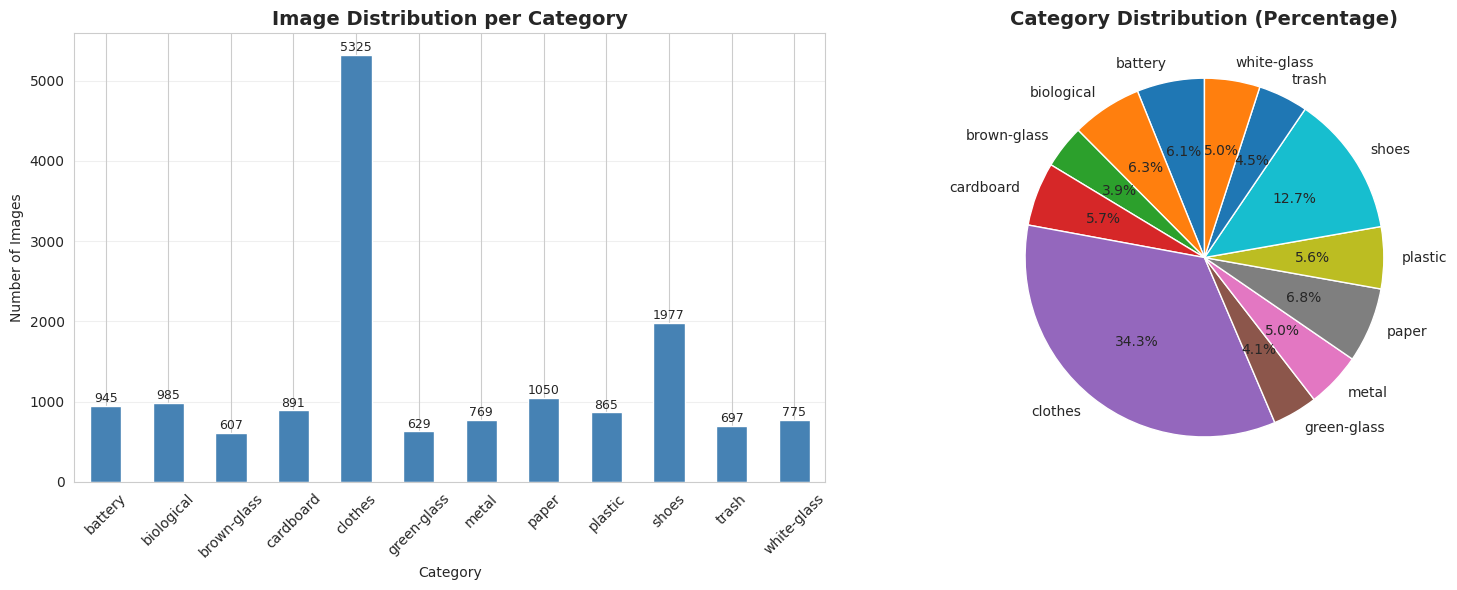

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

category_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Image Distribution per Category', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Number of Images')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

for i, v in enumerate(category_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', va='bottom', fontsize=9)

axes[1].pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Category Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'category_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Image Dimension Analysis

In [7]:
print("Image dimensions statistics:")
print(f"\nWidth - Mean: {df_dataset['width'].mean():.2f}, Std: {df_dataset['width'].std():.2f}")
print(f"Width - Min: {df_dataset['width'].min()}, Max: {df_dataset['width'].max()}")
print(f"\nHeight - Mean: {df_dataset['height'].mean():.2f}, Std: {df_dataset['height'].std():.2f}")
print(f"Height - Min: {df_dataset['height'].min()}, Max: {df_dataset['height'].max()}")
print(f"\nAspect Ratio - Mean: {df_dataset['aspect_ratio'].mean():.2f}, Std: {df_dataset['aspect_ratio'].std():.2f}")

unique_dimensions = df_dataset.groupby(['width', 'height']).size().reset_index(name='count')
print(f"\nUnique dimension combinations: {len(unique_dimensions)}")
print("\nTop 10 most common dimensions:")
print(unique_dimensions.nlargest(10, 'count'))

Image dimensions statistics:

Width - Mean: 349.82, Std: 117.55
Width - Min: 51, Max: 888

Height - Mean: 351.71, Std: 149.42
Height - Min: 100, Max: 936

Aspect Ratio - Mean: 1.08, Std: 0.35

Unique dimension combinations: 892

Top 10 most common dimensions:
     width  height  count
609    400     533   2590
824    512     384   2358
245    225     225   2004
610    400     534   1077
359    275     183    691
330    259     194    550
831    533     400    388
717    400     711    300
143    194     259    230
832    534     400    163


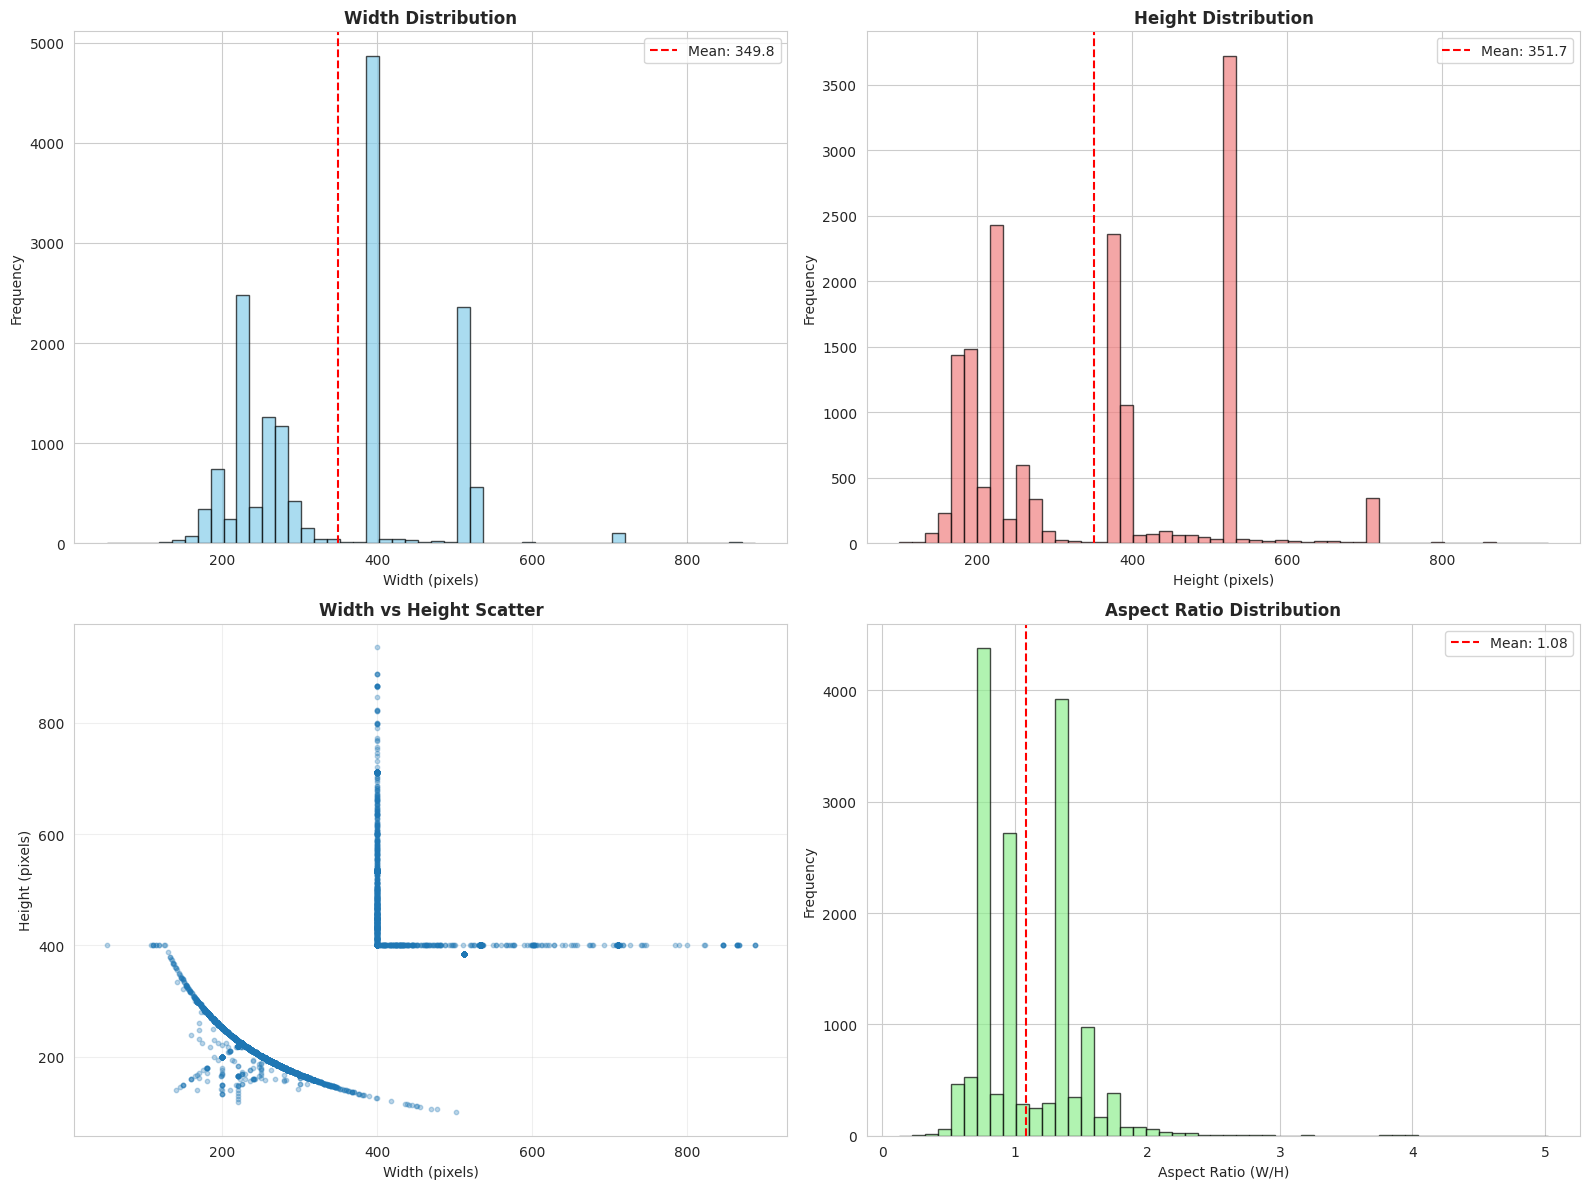

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].hist(df_dataset['width'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Width Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Width (pixels)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(df_dataset['width'].mean(), color='red', linestyle='--', label=f"Mean: {df_dataset['width'].mean():.1f}")
axes[0, 0].legend()

axes[0, 1].hist(df_dataset['height'], bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Height Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Height (pixels)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(df_dataset['height'].mean(), color='red', linestyle='--', label=f"Mean: {df_dataset['height'].mean():.1f}")
axes[0, 1].legend()

axes[1, 0].scatter(df_dataset['width'], df_dataset['height'], alpha=0.3, s=10)
axes[1, 0].set_title('Width vs Height Scatter', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Width (pixels)')
axes[1, 0].set_ylabel('Height (pixels)')
axes[1, 0].grid(alpha=0.3)

axes[1, 1].hist(df_dataset['aspect_ratio'], bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Aspect Ratio Distribution', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Aspect Ratio (W/H)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].axvline(df_dataset['aspect_ratio'].mean(), color='red', linestyle='--', label=f"Mean: {df_dataset['aspect_ratio'].mean():.2f}")
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'dimension_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Image Format & Mode Analysis

In [9]:
print("Image format distribution:")
print(df_dataset['format'].value_counts())

print("\nImage mode distribution:")
print(df_dataset['mode'].value_counts())

print("\nImage channels distribution:")
print(df_dataset['channels'].value_counts())

print("\nFile size statistics (KB):")
print(df_dataset['size_kb'].describe())

Image format distribution:
format
JPEG    15481
PNG        34
Name: count, dtype: int64

Image mode distribution:
mode
RGB    15481
P         34
Name: count, dtype: int64

Image channels distribution:
channels
3    15481
1       34
Name: count, dtype: int64

File size statistics (KB):
count    15515.000000
mean        15.767770
std         12.094970
min          1.047852
25%          5.804688
50%         12.764648
75%         22.713867
max         85.656250
Name: size_kb, dtype: float64


## 7. Pixel Intensity Analysis

In [10]:
print("Pixel intensity statistics:")
print(f"\nMean pixel value across all images: {df_dataset['mean_pixel'].mean():.2f}")
print(f"Std pixel value across all images: {df_dataset['std_pixel'].mean():.2f}")
print(f"\nGlobal min pixel: {df_dataset['min_pixel'].min()}")
print(f"Global max pixel: {df_dataset['max_pixel'].max()}")

pixel_stats_by_category = df_dataset.groupby('category')[['mean_pixel', 'std_pixel']].mean()
print("\nPixel statistics by category:")
print(pixel_stats_by_category)

Pixel intensity statistics:

Mean pixel value across all images: 157.60
Std pixel value across all images: 58.20

Global min pixel: 0
Global max pixel: 255

Pixel statistics by category:
             mean_pixel  std_pixel
category                          
battery      187.261238  75.486842
biological   139.625124  66.330951
brown-glass  173.643897  73.550489
cardboard    166.508620  53.782356
clothes      126.328383  58.943795
green-glass  172.436332  69.225567
metal        176.095969  55.628815
paper        166.140596  55.079082
plastic      183.835431  43.163415
shoes        162.960916  65.166270
trash        214.715562  32.575462
white-glass  200.084955  34.560155


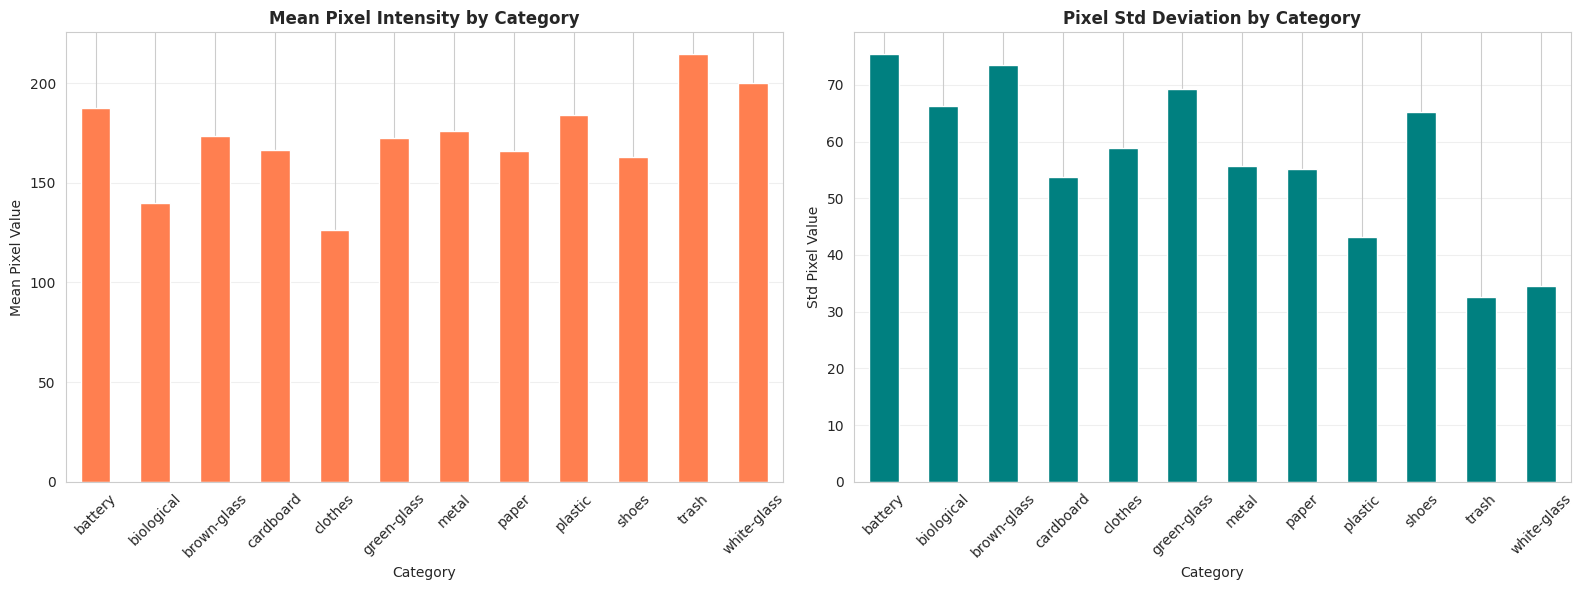

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pixel_stats_by_category['mean_pixel'].plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('Mean Pixel Intensity by Category', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Mean Pixel Value')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

pixel_stats_by_category['std_pixel'].plot(kind='bar', ax=axes[1], color='teal')
axes[1].set_title('Pixel Std Deviation by Category', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Std Pixel Value')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pixel_intensity_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Sample Images

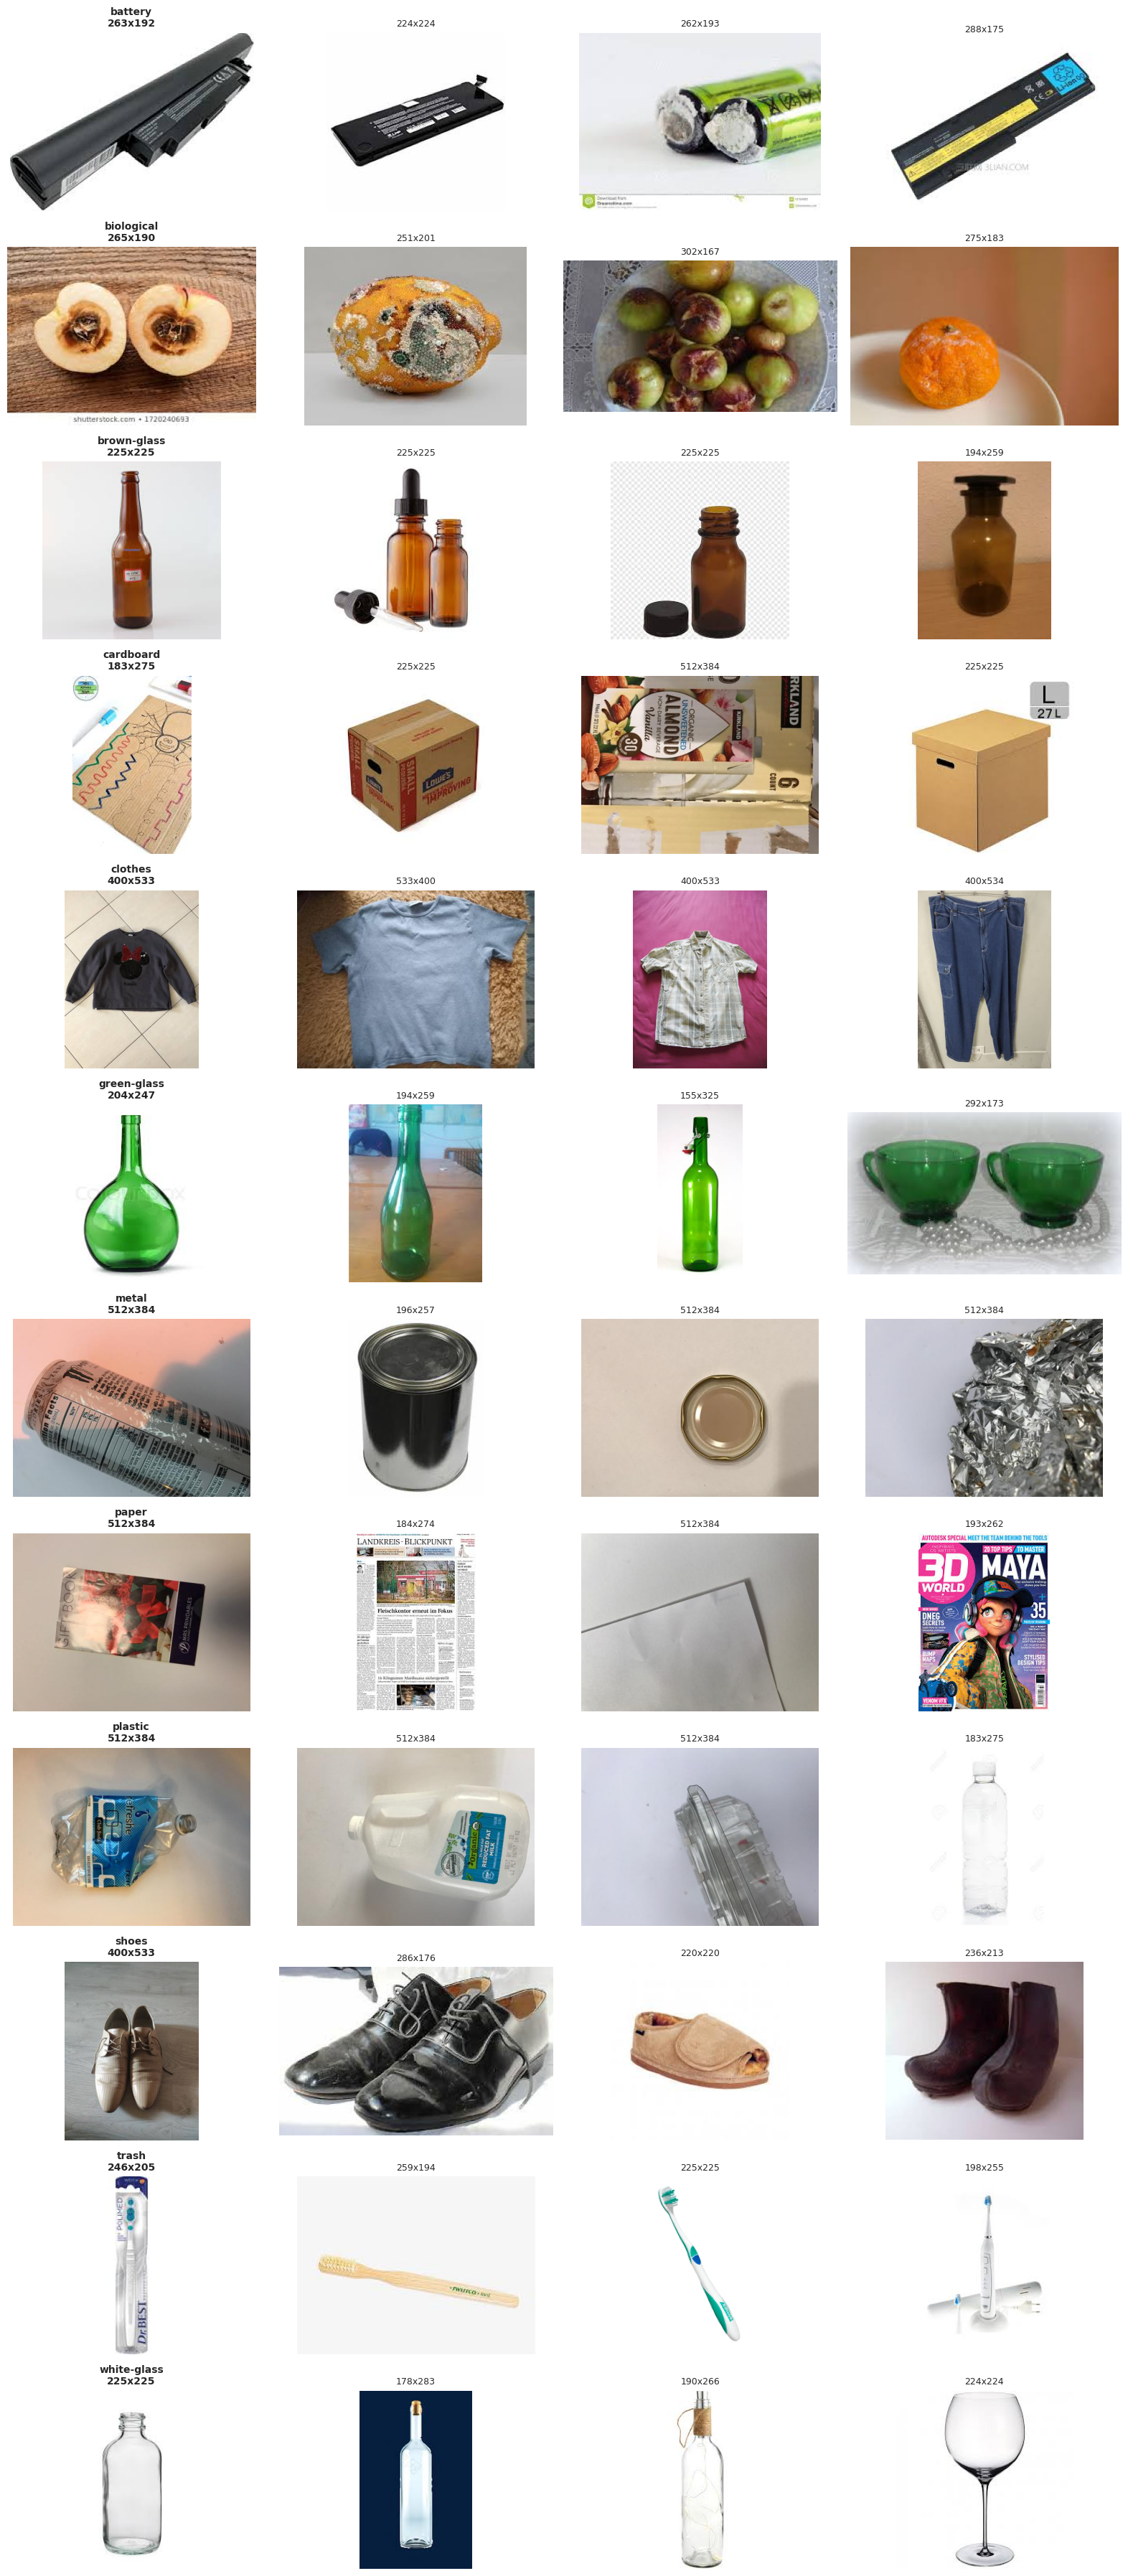

In [ ]:
def show_sample_images(df, categories, samples_per_category=3):
    """
    Show sample images from each category
    """
    n_cols = samples_per_category
    n_rows = len(categories)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
    
    for i, category in enumerate(categories):
        category_df = df[df['category'] == category]
        samples = category_df.sample(min(samples_per_category, len(category_df)))
        
        for j, (_, row) in enumerate(samples.iterrows()):
            if n_rows == 1:
                ax = axes[j]
            else:
                ax = axes[i, j] if n_cols > 1 else axes[i]
            
            img = Image.open(row['path'])
            ax.imshow(img)
            ax.axis('off')
            
            if j == 0:
                ax.set_title(f"{category}\n{row['width']}x{row['height']}", fontsize=10, fontweight='bold')
            else:
                ax.set_title(f"{row['width']}x{row['height']}", fontsize=9)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'sample_images.png', dpi=150, bbox_inches='tight')
    plt.show()

show_sample_images(df_dataset, categories, samples_per_category=4)

## 9. Data Quality Check

In [ ]:
def check_data_quality(df):
    """
    Check for data quality issues in the dataset
    """
    issues = []
    
    non_rgb = df[df['mode'] != 'RGB']
    if len(non_rgb) > 0:
        issues.append(f"Found {len(non_rgb)} non-RGB images")
    
    non_3_channel = df[df['channels'] != 3]
    if len(non_3_channel) > 0:
        issues.append(f"Found {len(non_3_channel)} images with channels != 3")
    
    small_images = df[(df['width'] < 50) | (df['height'] < 50)]
    if len(small_images) > 0:
        issues.append(f"Found {len(small_images)} very small images (< 50px)")
    
    extreme_aspect = df[(df['aspect_ratio'] > 3) | (df['aspect_ratio'] < 0.33)]
    if len(extreme_aspect) > 0:
        issues.append(f"Found {len(extreme_aspect)} images with extreme aspect ratios")
    
    return issues

quality_issues = check_data_quality(df_dataset)
if quality_issues:
    print("Data quality issues found:")
    for issue in quality_issues:
        print(f"- {issue}")
else:
    print("No major data quality issues detected")

Data quality issues found:
- Found 34 non-RGB images
- Found 34 images with channels != 3
- Found 25 images with extreme aspect ratios


## 10. Preprocessing

In [14]:
TARGET_SIZE = (224, 224)
NORMALIZATION = 'standard'

preprocessing_config = {
    'target_size': TARGET_SIZE,
    'normalization': NORMALIZATION,
    'color_mode': 'rgb',
    'interpolation': 'bilinear',
    'data_augmentation': {
        'rotation_range': 20,
        'width_shift_range': 0.2,
        'height_shift_range': 0.2,
        'shear_range': 0.15,
        'zoom_range': 0.2,
        'horizontal_flip': True,
        'fill_mode': 'nearest'
    },
    'split_ratio': {
        'train': 0.8,
        'val': 0.1,
        'test': 0.1
    }
}

with open(OUTPUT_DIR / 'preprocessing_config.json', 'w') as f:
    json.dump(preprocessing_config, f, indent=2)

print("Preprocessing configuration:")
print(json.dumps(preprocessing_config, indent=2))

Preprocessing configuration:
{
  "target_size": [
    224,
    224
  ],
  "normalization": "standard",
  "color_mode": "rgb",
  "interpolation": "bilinear",
  "data_augmentation": {
    "rotation_range": 20,
    "width_shift_range": 0.2,
    "height_shift_range": 0.2,
    "shear_range": 0.15,
    "zoom_range": 0.2,
    "horizontal_flip": true,
    "fill_mode": "nearest"
  },
  "split_ratio": {
    "train": 0.8,
    "val": 0.1,
    "test": 0.1
  }
}


## 11. Image Preprocessing Function

In [ ]:
def preprocess_image(img_path, target_size=(224, 224), normalize=True):
    """
    Preprocess images with resize, RGB conversion, and normalization
    """
    try:
        img = Image.open(img_path)
        
        if img.mode != 'RGB':
            img = img.convert('RGB')
        
        img = img.resize(target_size, Image.BILINEAR)
        
        img_array = np.array(img, dtype=np.float32)
        
        if normalize:
            img_array = img_array / 255.0
        
        return img_array, True
    except Exception as e:
        print(f"Error preprocessing {img_path}: {e}")
        return None, False

sample_img_path = df_dataset.iloc[0]['path']
processed_img, success = preprocess_image(sample_img_path)

if success:
    print(f"Preprocessing test successful")
    print(f"Original shape: {Image.open(sample_img_path).size}")
    print(f"Processed shape: {processed_img.shape}")
    print(f"Value range: [{processed_img.min():.4f}, {processed_img.max():.4f}]")
    print(f"Mean: {processed_img.mean():.4f}, Std: {processed_img.std():.4f}")

Preprocessing test successful
Original shape: (280, 180)
Processed shape: (224, 224, 3)
Value range: [0.0000, 1.0000]
Mean: 0.5472, Std: 0.2370


## 12. Train-Val-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

def split_dataset(df, train_ratio=0.8, val_ratio=0.1, test_ratio=0.1, random_state=42):
    """
    Split dataset into train, validation, and test sets with stratification
    """
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6, "Ratios must sum to 1"
    
    train_data = []
    val_data = []
    test_data = []
    
    for category in df['category'].unique():
        category_df = df[df['category'] == category].copy()
        
        train_df, temp_df = train_test_split(
            category_df,
            test_size=(1 - train_ratio),
            random_state=random_state,
            shuffle=True
        )
        
        val_size = val_ratio / (val_ratio + test_ratio)
        val_df, test_df = train_test_split(
            temp_df,
            test_size=(1 - val_size),
            random_state=random_state,
            shuffle=True
        )
        
        train_data.append(train_df)
        val_data.append(val_df)
        test_data.append(test_df)
    
    train_df = pd.concat(train_data, ignore_index=True)
    val_df = pd.concat(val_data, ignore_index=True)
    test_df = pd.concat(test_data, ignore_index=True)
    
    return train_df, val_df, test_df

train_df, val_df, test_df = split_dataset(
    df_dataset,
    train_ratio=0.8,
    val_ratio=0.1,
    test_ratio=0.1,
    random_state=42
)

print(f"Train set: {len(train_df)} images")
print(f"Validation set: {len(val_df)} images")
print(f"Test set: {len(test_df)} images")
print(f"\nTotal: {len(train_df) + len(val_df) + len(test_df)} images")

print("\nTrain distribution:")
print(train_df['category'].value_counts().sort_index())
print("\nValidation distribution:")
print(val_df['category'].value_counts().sort_index())
print("\nTest distribution:")
print(test_df['category'].value_counts().sort_index())

Train set: 12409 images
Validation set: 1550 images
Test set: 1556 images

Total: 15515 images

Train distribution:
category
battery         756
biological      788
brown-glass     485
cardboard       712
clothes        4260
green-glass     503
metal           615
paper           840
plastic         692
shoes          1581
trash           557
white-glass     620
Name: count, dtype: int64

Validation distribution:
category
battery         94
biological      98
brown-glass     61
cardboard       89
clothes        532
green-glass     63
metal           77
paper          105
plastic         86
shoes          198
trash           70
white-glass     77
Name: count, dtype: int64

Test distribution:
category
battery         95
biological      99
brown-glass     61
cardboard       90
clothes        533
green-glass     63
metal           77
paper          105
plastic         87
shoes          198
trash           70
white-glass     78
Name: count, dtype: int64


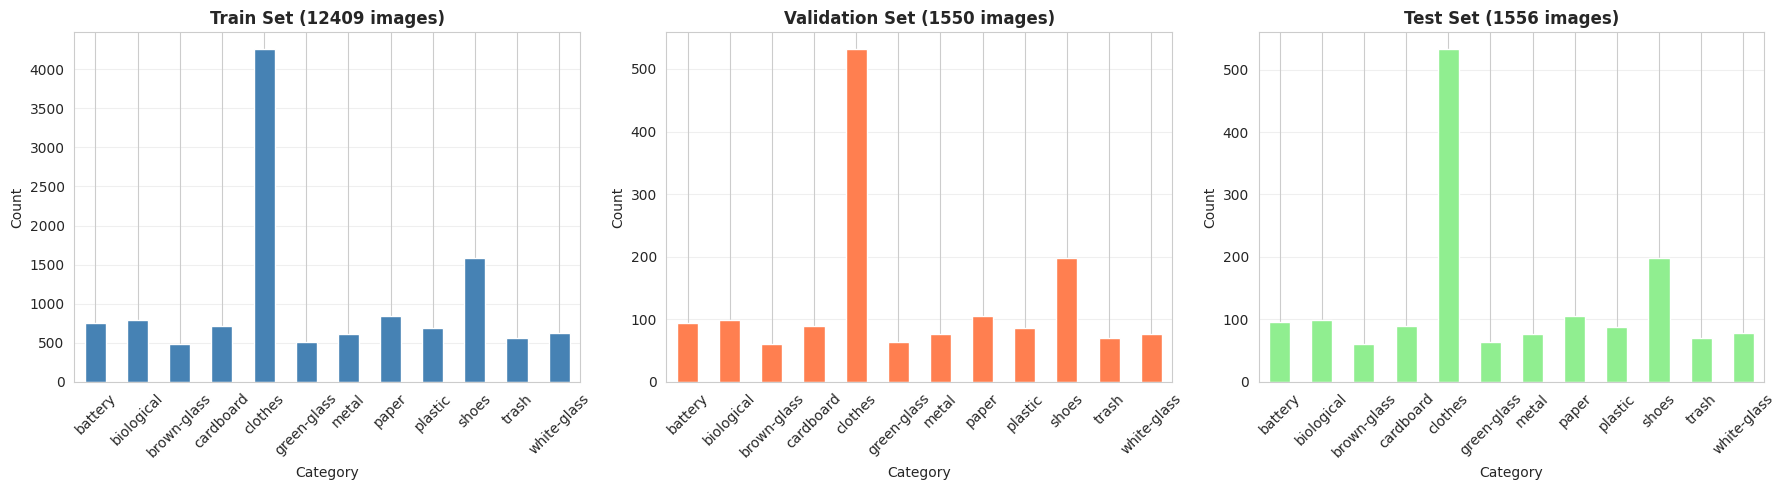

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

train_counts = train_df['category'].value_counts().sort_index()
val_counts = val_df['category'].value_counts().sort_index()
test_counts = test_df['category'].value_counts().sort_index()

train_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title(f'Train Set ({len(train_df)} images)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

val_counts.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title(f'Validation Set ({len(val_df)} images)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

test_counts.plot(kind='bar', ax=axes[2], color='lightgreen')
axes[2].set_title(f'Test Set ({len(test_df)} images)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Category')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'train_val_test_split.png', dpi=300, bbox_inches='tight')
plt.show()

## 13. Copy Files to Split Directories

In [ ]:
def copy_files_to_split_dirs(train_df, val_df, test_df, train_dir, val_dir, test_dir):
    """
    Copy files to their respective train, val, and test directories
    """
    splits = [
        (train_df, train_dir, 'train'),
        (val_df, val_dir, 'val'),
        (test_df, test_dir, 'test')
    ]
    
    for df, base_dir, split_name in splits:
        for category in df['category'].unique():
            category_dir = base_dir / category
            category_dir.mkdir(exist_ok=True, parents=True)
        
        print(f"Copying {split_name} files...")
        for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Copying {split_name}"):
            src_path = Path(row['path'])
            dst_path = base_dir / row['category'] / row['filename']
            
            if not dst_path.exists():
                shutil.copy2(src_path, dst_path)

copy_files_to_split_dirs(train_df, val_df, test_df, TRAIN_DIR, VAL_DIR, TEST_DIR)
print("\nFiles copied successfully")

Copying train files...


Copying train: 100%|██████████| 12409/12409 [04:07<00:00, 50.11it/s]


Copying val files...


Copying val: 100%|██████████| 1550/1550 [00:30<00:00, 50.34it/s]


Copying test files...


Copying test: 100%|██████████| 1556/1556 [00:31<00:00, 49.99it/s]


Files copied successfully


## 14. Save Split Information

In [20]:
train_df.to_csv(OUTPUT_DIR / 'train_split.csv', index=False)
val_df.to_csv(OUTPUT_DIR / 'val_split.csv', index=False)
test_df.to_csv(OUTPUT_DIR / 'test_split.csv', index=False)
df_dataset.to_csv(OUTPUT_DIR / 'full_dataset_info.csv', index=False)

print("Split information saved to CSV files")

Split information saved to CSV files


## 15. Summary & Overview

In [21]:
summary_report = {
    'dataset_overview': {
        'total_images': len(df_dataset),
        'total_categories': len(categories),
        'categories': categories,
        'images_per_category': category_counts.to_dict()
    },
    'image_statistics': {
        'dimensions': {
            'width_mean': float(df_dataset['width'].mean()),
            'width_std': float(df_dataset['width'].std()),
            'height_mean': float(df_dataset['height'].mean()),
            'height_std': float(df_dataset['height'].std()),
            'aspect_ratio_mean': float(df_dataset['aspect_ratio'].mean())
        },
        'pixel_intensity': {
            'mean': float(df_dataset['mean_pixel'].mean()),
            'std': float(df_dataset['std_pixel'].mean())
        },
        'file_size_kb': {
            'mean': float(df_dataset['size_kb'].mean()),
            'median': float(df_dataset['size_kb'].median())
        }
    },
    'data_split': {
        'train': {
            'total': len(train_df),
            'distribution': train_df['category'].value_counts().sort_index().to_dict()
        },
        'validation': {
            'total': len(val_df),
            'distribution': val_df['category'].value_counts().sort_index().to_dict()
        },
        'test': {
            'total': len(test_df),
            'distribution': test_df['category'].value_counts().sort_index().to_dict()
        }
    },
    'preprocessing_config': preprocessing_config,
    'data_quality': {
        'issues_found': quality_issues if quality_issues else ['No major issues']
    }
}

with open(OUTPUT_DIR / 'dataset_summary_report.json', 'w') as f:
    json.dump(summary_report, f, indent=2)

print("Summary report saved")
print("\nDataset Summary:")
print(json.dumps(summary_report, indent=2))

Summary report saved

Dataset Summary:
{
  "dataset_overview": {
    "total_images": 15515,
    "total_categories": 12,
    "categories": [
      "battery",
      "biological",
      "brown-glass",
      "cardboard",
      "clothes",
      "green-glass",
      "metal",
      "paper",
      "plastic",
      "shoes",
      "trash",
      "white-glass"
    ],
    "images_per_category": {
      "battery": 945,
      "biological": 985,
      "brown-glass": 607,
      "cardboard": 891,
      "clothes": 5325,
      "green-glass": 629,
      "metal": 769,
      "paper": 1050,
      "plastic": 865,
      "shoes": 1977,
      "trash": 697,
      "white-glass": 775
    }
  },
  "image_statistics": {
    "dimensions": {
      "width_mean": 349.8223009990332,
      "width_std": 117.54854366963035,
      "height_mean": 351.705833064776,
      "height_std": 149.4184867957969,
      "aspect_ratio_mean": 1.084210098662637
    },
    "pixel_intensity": {
      "mean": 157.601941651471,
      "std": 58.1